# EEG_35b — SI-DHGN: sweep λ_GRL (GRL troppo aggressivo?)

**Contesto (da EEG_35).** Nell'ablation completa tutti i lever anti-soggetto
(SMS, GRL, SupCon) peggioravano il test bACC rispetto al baseline (~0.255→~0.250).
Ipotesi: λ_max=0.50 e supcon_weight=0.30 potrebbero essere troppo aggressivi,
schiacciando l'embedding in una zona degenere senza lasciare spazio alla task loss.

**Domanda**: esiste un λ_GRL più basso che rimuova il bias soggetto senza distruggere
il segnale semantico? Si usa sempre SMS=True e un SupCon più leggero (w=0.10).

**Griglia**: λ_max ∈ {0.0, 0.02, 0.05, 0.10, 0.20} — seeds=[42, 123].

In [1]:
# ====================== §0 — Setup & Config — EEG_35b ======================
import json, logging, re, math
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Function
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from tqdm.auto import tqdm

try:
    import wandb
    _HAS_WANDB = True
except Exception:
    _HAS_WANDB = False

logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)-8s %(message)s', datefmt='%H:%M:%S')
log = logging.getLogger('eeg35')

project_root = next((p for p in [Path.cwd()]+list(Path.cwd().parents) if (p/'.git').exists()), Path.cwd())
FIG_DIR = project_root / 'figures'; FIG_DIR.mkdir(exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ---- DATI ----
N_CHANNELS  = 61
N_SAMPLES   = 384
N_CLASSES   = 4
DATA_METRIC = 'abs_pcc'
CLUSTER_SCHEME = 'concr4'
CLUSTER_NAMES  = ['CONCR', 'AZIONE', 'STATO', 'ASTR']

# Split subject-independent standard (identico a EEG_13/26/29/34)
SUBJ_TRAIN = list(range(0, 50))
SUBJ_VAL   = list(range(50, 60))
SUBJ_TEST  = list(range(60, 74))

# QUICK=True per smoke-test locale veloce (sottoinsieme soggetti, poche epoche)
QUICK = False
if QUICK:
    SUBJ_TRAIN, SUBJ_VAL, SUBJ_TEST = list(range(0,12)), list(range(50,54)), list(range(60,64))

# ---- ARCHITETTURA (backbone DHSLP, best config EEG_13) ----
K_WINDOWS = 8; T_WIN = N_SAMPLES // K_WINDOWS
N_EDGES   = 16      # n. iperedge apprese
D_MODEL   = 64      # dim proiezione nodo / spazio iperedge
D_ENC     = 128     # dim embedding latente (hidden HGNN)
N_LAYERS  = 2
DROPOUT   = 0.4     # dropout alto = regolarizzazione
DROPEDGE  = 0.10    # prob. di azzerare incidenze nodo-iperedge (DropEdge)

# ---- OTTIMIZZAZIONE ----
LR              = 1e-3
WEIGHT_DECAY    = 1e-3      # AdamW: regolarizzazione L2 disaccoppiata
BATCH_SIZE      = 64
MAX_EPOCHS      = 60 if not QUICK else 6
PATIENCE        = 12
WARMUP_EPOCHS   = 5
LABEL_SMOOTHING = 0.1
SEEDS           = [42, 123] if not QUICK else [42]     # 2 seed per velocità

# ---- LEVE ANTI-SOGGETTO (pesi loss / schedule) ----
LAMBDA_GRL_MAX  = 0.10      # ← verrà sovrascritto dal sweep; valore di default
SUPCON_WEIGHT   = 0.10      # più leggero di EEG_35 (era 0.30)
SUPCON_TAU      = 0.1       # temperatura SupCon

WANDB_ENTITY  = 'uras-daniele22-politecnico-di-milano'
WANDB_PROJECT = 'miralis-imagined-speech'
USE_WANDB     = _HAS_WANDB

_PAT = re.compile(r'^P(\d+)_S(\d+)$')
label2cluster = {int(k): int(v) for k, v in json.loads(
    (project_root/'configs'/'label_schemes'/'labelid2cluster_concr4.json').read_text()).items()}

log.info(f'device={device} | TRAIN={len(SUBJ_TRAIN)} VAL={len(SUBJ_VAL)} TEST={len(SUBJ_TEST)} | QUICK={QUICK}')


/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(
17:26:37 INFO     device=cuda | TRAIN=50 VAL=10 TEST=14 | QUICK=False


In [2]:
# ====================== §1.1 — Medie per soggetto (SMS) ======================
def compute_subject_means(subj_ids, metric=DATA_METRIC):
    '''mu_s = media dei trial instance-norm del soggetto s -> dict sid -> (61,384).'''
    root = project_root / 'data' / f'hypergraphs_pruned_{metric}'
    accum = defaultdict(list)
    for p in sorted(root.rglob('trial_*.pt')):
        m = _PAT.match(p.parent.name)
        if not m: continue
        sid = int(m.group(1))
        if sid not in subj_ids: continue
        d = torch.load(p, weights_only=False)
        x = d['x'].float()
        x = (x - x.mean(1, keepdim=True)) / (x.std(1, keepdim=True) + 1e-6)
        accum[sid].append(x)
    means = {sid: torch.stack(t).mean(0) for sid, t in accum.items()}
    log.info(f'mu calcolate per {len(means)} soggetti')
    return means

DATA_ROOT = project_root / 'data' / f'hypergraphs_pruned_{DATA_METRIC}'
DATA_AVAILABLE = DATA_ROOT.exists() and any(DATA_ROOT.rglob('trial_*.pt'))
log.info(f'DATA_AVAILABLE={DATA_AVAILABLE} ({DATA_ROOT})')

subj_means = compute_subject_means(SUBJ_TRAIN + SUBJ_VAL + SUBJ_TEST) if DATA_AVAILABLE else {}


17:26:37 INFO     DATA_AVAILABLE=True (/home/daniele_u/miralis-hypergraph-imagined-speech/data/hypergraphs_pruned_abs_pcc)
17:27:05 INFO     mu calcolate per 74 soggetti


In [3]:
# ====================== §1.2 — Dataset & Loader ======================
class EEGDataset(Dataset):
    '''Restituisce (x(61,384), cluster_label, domain_idx). domain_idx = indice soggetto 0-based nello split.'''
    def __init__(self, subj_ids, subject_means=None, use_sms=False, metric=DATA_METRIC):
        root = project_root / 'data' / f'hypergraphs_pruned_{metric}'
        self.paths, self.labels, self.domains = [], [], []
        self.subject_means, self.use_sms = subject_means, use_sms
        subj2dom = {sid: i for i, sid in enumerate(sorted(subj_ids))}
        self._sids = []
        for p in sorted(root.rglob('trial_*.pt')):
            m = _PAT.match(p.parent.name)
            if not m: continue
            sid = int(m.group(1))
            if sid not in subj_ids: continue
            d = torch.load(p, weights_only=False)
            yw = int(d['y'].squeeze()) if isinstance(d['y'], torch.Tensor) else int(d['y'])
            c = label2cluster.get(yw)
            if c is None: continue
            self.paths.append(p); self.labels.append(c)
            self.domains.append(subj2dom[sid]); self._sids.append(sid)
        self.n_domains = len(subj2dom)
        log.info(f'  {len(self.paths)} trial | {len(subj_ids)} soggetti | SMS={use_sms}')

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        d = torch.load(self.paths[idx], weights_only=False)
        x = d['x'].float()
        x = (x - x.mean(1, keepdim=True)) / (x.std(1, keepdim=True) + 1e-6)   # instance norm sempre
        if self.use_sms and self.subject_means is not None:
            sid = self._sids[idx]
            if sid in self.subject_means:
                x = x - self.subject_means[sid]
        return (x,
                torch.tensor(self.labels[idx],  dtype=torch.long),
                torch.tensor(self.domains[idx], dtype=torch.long))


def make_loaders(use_sms):
    tr = EEGDataset(SUBJ_TRAIN, subj_means, use_sms=use_sms)
    va = EEGDataset(SUBJ_VAL,   subj_means, use_sms=use_sms)
    te = EEGDataset(SUBJ_TEST,  subj_means, use_sms=use_sms)
    labels = np.array(tr.labels)
    counts = np.bincount(labels, minlength=N_CLASSES)
    w = torch.tensor(1.0 / np.clip(counts[labels], 1, None), dtype=torch.float)
    sampler = WeightedRandomSampler(w, len(w), replacement=True)
    kw = dict(num_workers=2, pin_memory=True)
    return (DataLoader(tr, BATCH_SIZE, sampler=sampler, drop_last=True, **kw),
            DataLoader(va, BATCH_SIZE, shuffle=False, **kw),
            DataLoader(te, BATCH_SIZE, shuffle=False, **kw),
            tr.n_domains)


In [4]:
# ====================== §2.1 — GRL, HGNNConv, DropEdge ======================
class GradReverseFn(Function):
    @staticmethod
    def forward(ctx, x, lam):
        ctx.lam = lam
        return x.clone()
    @staticmethod
    def backward(ctx, g):
        return -ctx.lam * g, None

class GRL(nn.Module):
    def forward(self, x, lam=1.0): return GradReverseFn.apply(x, lam)

def grl_lambda(step, total, lam_max):
    '''Schedule di Ganin 2016: 0 -> lam_max, sigmoidale.'''
    p = step / max(total, 1)
    return float(lam_max * (2.0 / (1.0 + math.exp(-10.0 * p)) - 1.0))

class HGNNConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(in_ch, out_ch))
        self.bias   = nn.Parameter(torch.zeros(out_ch))
        nn.init.xavier_uniform_(self.weight)
    def forward(self, X, H):
        d_v = H.sum(2).clamp(min=1e-6); d_e = H.sum(1).clamp(min=1e-6)
        Dv  = (1.0/d_v.sqrt()).unsqueeze(-1); De = (1.0/d_e).unsqueeze(1)
        out = Dv * (X @ self.weight)
        out = torch.bmm(H.transpose(1,2), out)
        out = De.transpose(1,2) * out
        out = torch.bmm(H, out)
        return Dv * out + self.bias

def drop_edge(H, p, training):
    '''Azzera con prob. p le incidenze nodo-iperedge di H (B,N,E) e rinormalizza su E.'''
    if not training or p <= 0:
        return H
    mask = (torch.rand_like(H) > p).float()
    H = H * mask
    H = H / (H.sum(dim=2, keepdim=True) + 1e-6)   # rinormalizza la softmax sui rami superstiti
    return H


In [5]:
# ====================== §2.2 — Modello SI-DHGN ======================
class DHSLPEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.E       = nn.Parameter(torch.randn(N_EDGES, D_MODEL) * 0.01)
        self.pos_enc = nn.Parameter(torch.randn(N_CHANNELS, D_MODEL) * 0.01)
        self.node_proj = nn.Sequential(nn.Linear(T_WIN, D_MODEL), nn.LayerNorm(D_MODEL), nn.ELU())
        dims = [D_MODEL] + [D_ENC] * N_LAYERS
        self.convs = nn.ModuleList([HGNNConv(dims[i], dims[i+1]) for i in range(N_LAYERS)])
        self.bns   = nn.ModuleList([nn.BatchNorm1d(D_ENC) for _ in range(N_LAYERS)])
        self.drop  = nn.Dropout(DROPOUT)
    def forward(self, x):
        B, N, _ = x.shape
        outs = []
        for k in range(K_WINDOWS):
            x_k  = x[:, :, k*T_WIN:(k+1)*T_WIN]
            feat = self.node_proj(x_k) + self.pos_enc
            H_k  = torch.softmax(torch.matmul(feat, self.E.T) / D_MODEL**0.5, dim=2)
            H_k  = drop_edge(H_k, DROPEDGE, self.training)
            out  = feat
            for conv, bn in zip(self.convs, self.bns):
                out = conv(out, H_k)
                out = bn(out.reshape(B*N, -1)).reshape(B, N, -1)
                out = F.relu(out); out = self.drop(out)
            outs.append(out.mean(1))
        return torch.stack(outs, 1).mean(1)   # (B, D_ENC)

class SIDHGN(nn.Module):
    '''Subject-Invariant Dynamic Hypergraph Net. Flag: use_grl, use_supcon attivano le teste extra.'''
    def __init__(self, n_domains, use_grl=True, use_supcon=True, proj_dim=64):
        super().__init__()
        self.use_grl, self.use_supcon = use_grl, use_supcon
        self.encoder = DHSLPEncoder()
        self.task_clf = nn.Sequential(nn.Linear(D_ENC, D_ENC//2), nn.ReLU(),
                                      nn.Dropout(DROPOUT), nn.Linear(D_ENC//2, N_CLASSES))
        if use_grl:
            self.grl = GRL()
            self.domain_clf = nn.Sequential(nn.Linear(D_ENC, D_ENC//2), nn.ReLU(),
                                            nn.Dropout(DROPOUT), nn.Linear(D_ENC//2, n_domains))
        if use_supcon:
            self.proj = nn.Sequential(nn.Linear(D_ENC, D_ENC), nn.ReLU(), nn.Linear(D_ENC, proj_dim))
    def forward(self, x, lam=1.0):
        z = self.encoder(x)
        task = self.task_clf(z)
        dom  = self.domain_clf(self.grl(z, lam)) if self.use_grl else None
        emb  = F.normalize(self.proj(z), dim=1) if self.use_supcon else None
        return task, dom, emb

def supcon_loss(emb, labels, tau=SUPCON_TAU):
    '''Supervised Contrastive (Khosla 2020). emb L2-norm (B,d). Positivi = stesso cluster.'''
    B = emb.shape[0]
    sim = emb @ emb.T / tau
    sim = sim - sim.max(dim=1, keepdim=True).values.detach()
    eye = torch.eye(B, device=emb.device, dtype=torch.bool)
    same = (labels.unsqueeze(0) == labels.unsqueeze(1)) & ~eye
    exp = torch.exp(sim) * (~eye).float()
    log_prob = sim - torch.log(exp.sum(1, keepdim=True) + 1e-9)
    pos_cnt = same.sum(1)
    valid = pos_cnt > 0
    if valid.sum() == 0:
        return emb.sum() * 0.0
    mean_pos = (log_prob * same.float()).sum(1)[valid] / pos_cnt[valid]
    return -mean_pos.mean()

# Sanity
if True:
    _m = SIDHGN(n_domains=23).to(device)
    _t,_d,_e = _m(torch.randn(4,N_CHANNELS,N_SAMPLES).to(device), lam=0.5)
    assert _t.shape==(4,N_CLASSES) and _d.shape==(4,23) and _e.shape[0]==4
    log.info(f'SIDHGN OK — {sum(p.numel() for p in _m.parameters() if p.requires_grad):,} param')
    del _m,_t,_d,_e


17:27:06 INFO     SIDHGN OK — 76,571 param


In [6]:
# ====================== §3.1 — Loop di training ======================
def set_seed(s):
    torch.manual_seed(s); np.random.seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)

@torch.no_grad()
def evaluate(model, loader):
    model.eval(); ys, ps = [], []
    for x, y, _ in loader:
        x = x.to(device)
        logits, _, _ = model(x, lam=0.0)
        ps.append(logits.argmax(1).cpu()); ys.append(y)
    y = torch.cat(ys).numpy(); p = torch.cat(ps).numpy()
    return balanced_accuracy_score(y, p), y, p

def train_model(name, use_sms, use_grl, use_supcon, seed, run=None):
    set_seed(seed)
    tr_loader, va_loader, te_loader, n_dom = make_loaders(use_sms)
    model = SIDHGN(n_dom, use_grl=use_grl, use_supcon=use_supcon).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    ce  = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    ce_dom = nn.CrossEntropyLoss()

    total_steps = MAX_EPOCHS * max(len(tr_loader), 1)
    def lr_at(step):
        ep = step / max(len(tr_loader), 1)
        if ep < WARMUP_EPOCHS:
            return ep / max(WARMUP_EPOCHS, 1e-9)
        prog = (ep - WARMUP_EPOCHS) / max(MAX_EPOCHS - WARMUP_EPOCHS, 1e-9)
        return 0.5 * (1.0 + math.cos(math.pi * min(prog, 1.0)))

    best_va, best_state, bad, step = -1.0, None, 0, 0
    for epoch in range(MAX_EPOCHS):
        model.train(); agg = defaultdict(float); nb = 0
        for x, y, dom in tr_loader:
            x, y, dom = x.to(device), y.to(device), dom.to(device)
            for g in opt.param_groups: g['lr'] = LR * lr_at(step)
            lam = grl_lambda(step, total_steps, LAMBDA_GRL_MAX) if use_grl else 0.0
            logits, dlog, emb = model(x, lam=lam)
            loss = ce(logits, y)
            l_dom = ce_dom(dlog, dom) if use_grl else torch.zeros((), device=device)
            l_sc  = supcon_loss(emb, y) if use_supcon else torch.zeros((), device=device)
            loss = loss + (l_dom if use_grl else 0.0) + (SUPCON_WEIGHT * l_sc if use_supcon else 0.0)
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
            agg['task'] += ce(logits, y).item(); agg['dom'] += float(l_dom); agg['sc'] += float(l_sc)
            nb += 1; step += 1
        va_bacc, _, _ = evaluate(model, va_loader)
        if run is not None:
            run.log({'train/task_loss': agg['task']/max(nb,1), 'train/dom_loss': agg['dom']/max(nb,1),
                     'train/supcon_loss': agg['sc']/max(nb,1), 'val/bacc': va_bacc,
                     'lam_grl': lam, 'lr': LR*lr_at(step), 'epoch': epoch})
        if va_bacc > best_va:
            best_va, best_state, bad = va_bacc, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
        else:
            bad += 1
        log.info(f'[{name} s{seed}] ep{epoch:02d} val_bACC={va_bacc:.4f} (best={best_va:.4f}) '
                 f'task={agg["task"]/max(nb,1):.3f} dom={agg["dom"]/max(nb,1):.3f} sc={agg["sc"]/max(nb,1):.3f}')
        if bad >= PATIENCE:
            log.info(f'[{name} s{seed}] early stop @ep{epoch}'); break

    if best_state is not None: model.load_state_dict(best_state)
    te_bacc, y_te, p_te = evaluate(model, te_loader)
    log.info(f'[{name} s{seed}] >>> val_bACC={best_va:.4f}  test_bACC={te_bacc:.4f}')
    return dict(val_bacc=best_va, test_bacc=te_bacc, y_te=y_te, p_te=p_te)


## §4 — Sweep λ_GRL

Per ogni valore di λ_max addestriamo il modello completo (SMS=True, GRL=True, SupCon=True)
con `supcon_weight=0.10`. λ=0.0 equivale a GRL disattivato (SMS+SupCon only).

I risultati EEG_35 (λ=0.50, supcon_weight=0.30) sono inclusi come riferimento testuale
ma **non rieseguiti** per risparmiare tempo.

In [7]:
# ====================== §4.1 — Sweep λ_GRL ======================
# Tutti usano: SMS=True, GRL=True (tranne λ=0.0), SupCon=True, supcon_weight=0.10
# λ=0.0 → GRL disattivato (solo SMS + SupCon leggero)

LAMBDA_SWEEP = [0.0, 0.02, 0.05, 0.10, 0.20]

results = {}
if DATA_AVAILABLE:
    for lam_val in LAMBDA_SWEEP:
        name = f'λ{lam_val:.2f}'.replace('0.', 'λ0')  # e.g. 'λ000', 'λ002'
        use_grl = (lam_val > 0.0)

        seed_res = []
        for seed in SEEDS:
            # Override globale di LAMBDA_GRL_MAX per questo run
            import builtins
            old_lam = LAMBDA_GRL_MAX
            # Monkey-patch il modulo corrente
            globals()['LAMBDA_GRL_MAX'] = lam_val

            run = None
            if USE_WANDB:
                try:
                    run = wandb.init(entity=WANDB_ENTITY, project=WANDB_PROJECT,
                                     name=f'eeg35b_{name}_{CLUSTER_SCHEME}_s{seed}',
                                     group='eeg35b_lambda_sweep',
                                     config=dict(notebook='EEG_35b', lambda_grl_max=lam_val,
                                                 supcon_weight=SUPCON_WEIGHT, use_sms=True,
                                                 use_grl=use_grl, use_supcon=True,
                                                 n_classes=N_CLASSES, cluster_scheme=CLUSTER_SCHEME,
                                                 lr=LR, weight_decay=WEIGHT_DECAY, batch_size=BATCH_SIZE,
                                                 max_epochs=MAX_EPOCHS, patience=PATIENCE,
                                                 k_windows=K_WINDOWS, n_edges=N_EDGES, d_enc=D_ENC,
                                                 dropout=DROPOUT, dropedge=DROPEDGE, seed=seed),
                                     reinit='finish_previous')
                except Exception as e:
                    log.warning(f'W&B init fallita ({e})'); run = None

            r = train_model(name, use_sms=True, use_grl=use_grl, use_supcon=True, seed=seed, run=run)

            globals()['LAMBDA_GRL_MAX'] = old_lam  # ripristina

            if run is not None:
                run.summary['val_bacc']  = r['val_bacc']
                run.summary['test_bacc'] = r['test_bacc']
                run.summary['lambda_grl_max'] = lam_val
                try:
                    run.log({'confusion_matrix': wandb.plot.confusion_matrix(
                        y_true=r['y_te'].tolist(), preds=r['p_te'].tolist(),
                        class_names=CLUSTER_NAMES)})
                except Exception: pass
                run.finish()
            seed_res.append(r)

        results[name] = seed_res
        vb = np.array([r['val_bacc'] for r in seed_res])
        tb = np.array([r['test_bacc'] for r in seed_res])
        log.info(f'=== λ={lam_val:.2f}: val {vb.mean():.4f}±{vb.std():.4f} | test {tb.mean():.4f}±{tb.std():.4f} ===')
else:
    log.warning('[INFO] Dati non disponibili in locale: esegui sul server (env daniele_311).')


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/daniele_u/.netrc.
wandb: Currently logged in as: uras-daniele22 (uras-daniele22-politecnico-di-milano) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


17:27:11 INFO       26123 trial | 50 soggetti | SMS=True
17:27:12 INFO       5500 trial | 10 soggetti | SMS=True
17:27:14 INFO       7260 trial | 14 soggetti | SMS=True
/tmp/ipykernel_82618/2301164452.py:47: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  agg['task'] += ce(logits, y).item(); agg['dom'] += float(l_dom); agg['sc'] += float(l_sc)
17:27:26 INFO     [λλ000 s42] ep00 val_bACC=0.2440 (best=0.2440) task=1.391 dom=0.000 sc=4.179
17:27:38 INFO     [λλ000 s42] ep01 val_bACC=0.2398 (best=0.2440) task=1.386 dom=0.000 sc=4.144
17:27:50 INFO     [λλ000 s42] ep02 val_bACC=0.2353 (best=0.2440) task=1.386 dom=0.000 sc=4.143
17:28:01 INFO     [λλ000 s42] ep03 val_bACC=0.2335 (best=0.2440) task=1.385 dom=0.000 sc=4.143
17:28:13 INFO     [λλ000 s42] ep04 val_bACC=0.2504 (best=0.2504) task=1.382 dom=0.

epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
lam_grl,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
lr,▁▃▅▆█████████▇▇▇▇▇▇▆▆▆▆▆▅▅▅▅▄▄▄▄▄▃▃▃▃▂
train/dom_loss,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/supcon_loss,█▇▇▇▇▇▇▇▇▇▇▇▇▆▆▆▆▆▆▆▅▅▅▅▄▄▄▄▃▃▃▃▂▂▂▁▁▁
train/task_loss,████████▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁▁
val/bacc,▄▃▁▁▆▄▅▆▅▄▅▄▆▅▇▅▇▆█▇▇▄▅▅▆█▂▅▅▅▅▄▃▃▄▃▄▄
epoch,37
lam_grl,0
lambda_grl_max,0
lr,0.00035


17:34:51 INFO       26123 trial | 50 soggetti | SMS=True
17:34:52 INFO       5500 trial | 10 soggetti | SMS=True
17:34:53 INFO       7260 trial | 14 soggetti | SMS=True
17:35:05 INFO     [λλ000 s123] ep00 val_bACC=0.2615 (best=0.2615) task=1.393 dom=0.000 sc=4.166
17:35:17 INFO     [λλ000 s123] ep01 val_bACC=0.2544 (best=0.2615) task=1.387 dom=0.000 sc=4.144
17:35:29 INFO     [λλ000 s123] ep02 val_bACC=0.2499 (best=0.2615) task=1.386 dom=0.000 sc=4.143
17:35:40 INFO     [λλ000 s123] ep03 val_bACC=0.2535 (best=0.2615) task=1.385 dom=0.000 sc=4.143
17:35:52 INFO     [λλ000 s123] ep04 val_bACC=0.2484 (best=0.2615) task=1.382 dom=0.000 sc=4.143
17:36:04 INFO     [λλ000 s123] ep05 val_bACC=0.2476 (best=0.2615) task=1.381 dom=0.000 sc=4.143
17:36:16 INFO     [λλ000 s123] ep06 val_bACC=0.2451 (best=0.2615) task=1.376 dom=0.000 sc=4.143
17:36:29 INFO     [λλ000 s123] ep07 val_bACC=0.2561 (best=0.2615) task=1.369 dom=0.000 sc=4.143
17:36:43 INFO     [λλ000 s123] ep08 val_bACC=0.2523 (best=0.261

epoch,▁▂▂▃▃▄▅▅▆▆▇▇█
lam_grl,▁▁▁▁▁▁▁▁▁▁▁▁▁
lr,▁▃▅▆█████████
train/dom_loss,▁▁▁▁▁▁▁▁▁▁▁▁▁
train/supcon_loss,█▃▃▃▃▃▃▃▃▂▂▂▁
train/task_loss,█▇▇▇▇▇▆▆▅▄▃▂▁
val/bacc,█▆▄▅▄▄▃▆▅▇▁▂▂
epoch,12
lam_grl,0
lambda_grl_max,0
lr,0.00095


...

18:08:46 INFO       26123 trial | 50 soggetti | SMS=True
18:08:47 INFO       5500 trial | 10 soggetti | SMS=True
18:08:48 INFO       7260 trial | 14 soggetti | SMS=True
18:09:01 INFO     [λλ020 s42] ep00 val_bACC=0.2370 (best=0.2370) task=1.391 dom=3.889 sc=4.167
18:09:13 INFO     [λλ020 s42] ep01 val_bACC=0.2509 (best=0.2509) task=1.387 dom=3.710 sc=4.144
18:09:26 INFO     [λλ020 s42] ep02 val_bACC=0.2471 (best=0.2509) task=1.386 dom=3.842 sc=4.143
18:09:38 INFO     [λλ020 s42] ep03 val_bACC=0.2468 (best=0.2509) task=1.386 dom=3.876 sc=4.143
18:09:51 INFO     [λλ020 s42] ep04 val_bACC=0.2359 (best=0.2509) task=1.385 dom=3.898 sc=4.143
18:10:03 INFO     [λλ020 s42] ep05 val_bACC=0.2514 (best=0.2514) task=1.382 dom=3.901 sc=4.143
18:10:16 INFO     [λλ020 s42] ep06 val_bACC=0.2443 (best=0.2514) task=1.379 dom=3.893 sc=4.143
18:10:30 INFO     [λλ020 s42] ep07 val_bACC=0.2418 (best=0.2514) task=1.376 dom=3.889 sc=4.143
18:10:42 INFO     [λλ020 s42] ep08 val_bACC=0.2484 (best=0.2514) task=1

epoch,▁▁▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇██
lam_grl,▁▂▂▃▃▄▅▅▅▆▆▆▇▇▇▇▇██████
lr,▁▃▅▆█████████▇▇▇▇▇▇▆▆▆▆
train/dom_loss,█▁▆▇████▇▇█▇▇▇▇▇▇▇▇▇▇▇▆
train/supcon_loss,█▅▅▅▅▅▅▅▅▅▅▅▅▄▄▄▄▃▃▃▂▁▁
train/task_loss,██████▇▇▇▇▆▆▅▅▄▄▃▃▃▂▂▁▁
val/bacc,▁▆▅▅▁▇▄▃▅▅█▄▅▂▄▄▄▅▃▅▅▅▆
epoch,22
lam_grl,0.19152
lambda_grl_max,0.2
lr,0.00076


18:13:49 INFO       26123 trial | 50 soggetti | SMS=True
18:13:50 INFO       5500 trial | 10 soggetti | SMS=True
18:13:51 INFO       7260 trial | 14 soggetti | SMS=True
18:14:03 INFO     [λλ020 s123] ep00 val_bACC=0.2513 (best=0.2513) task=1.395 dom=3.878 sc=4.172
18:14:16 INFO     [λλ020 s123] ep01 val_bACC=0.2570 (best=0.2570) task=1.387 dom=3.705 sc=4.144
18:14:28 INFO     [λλ020 s123] ep02 val_bACC=0.2532 (best=0.2570) task=1.386 dom=3.837 sc=4.143
18:14:41 INFO     [λλ020 s123] ep03 val_bACC=0.2486 (best=0.2570) task=1.386 dom=3.885 sc=4.143
18:14:54 INFO     [λλ020 s123] ep04 val_bACC=0.2451 (best=0.2570) task=1.385 dom=3.896 sc=4.143
18:15:06 INFO     [λλ020 s123] ep05 val_bACC=0.2519 (best=0.2570) task=1.384 dom=3.888 sc=4.143
18:15:19 INFO     [λλ020 s123] ep06 val_bACC=0.2499 (best=0.2570) task=1.382 dom=3.880 sc=4.143
18:15:32 INFO     [λλ020 s123] ep07 val_bACC=0.2589 (best=0.2589) task=1.380 dom=3.885 sc=4.143
18:15:44 INFO     [λλ020 s123] ep08 val_bACC=0.2526 (best=0.258

epoch,▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇██
lam_grl,▁▂▂▃▃▄▄▅▅▆▆▆▇▇▇▇▇▇██████████
lr,▁▃▅▆█████████▇▇▇▇▇▇▆▆▆▆▆▅▅▅▅
train/dom_loss,▇▁▆▇██▇▇██████▇▇▇▇▇▇▇▇▇▇▇▆▆▆
train/supcon_loss,█▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▄▄▄▄▃▃▂▂▂▁▁
train/task_loss,████▇▇▇▇▇▇▇▆▆▆▅▅▅▄▄▄▃▃▃▂▂▂▁▁
val/bacc,▄▆▅▃▂▄▄▇▅▅▄▆▃▁▃█▆▂▃▂▂▅▂▆▃▃▁▄
epoch,27
lam_grl,0.19627
lambda_grl_max,0.2
lr,0.00063


18:19:49 INFO     === λ=0.20: val 0.2591±0.0036 | test 0.2501±0.0022 ===


## §5 — Risultati: sweep λ_GRL

18:19:50 INFO     Figura: /home/daniele_u/miralis-hypergraph-imagined-speech/figures/eeg35b_lambda_sweep.png


 lambda_grl              config  val_bacc  val_std  test_bacc  test_std
       0.00               λλ000  0.260665 0.000802   0.250893  0.006431
       0.02               λλ002  0.254802 0.004295   0.257575  0.004567
       0.05               λλ005  0.257077 0.002029   0.252513  0.001909
       0.10               λλ010  0.258189 0.001162   0.251127  0.000626
       0.20               λλ020  0.259148 0.003644   0.250056  0.002218
       0.50     EEG35_full(ref)  0.254700 0.001600   0.249900  0.001100
        NaN EEG35_baseline(ref)  0.260800 0.003500   0.255600  0.002500


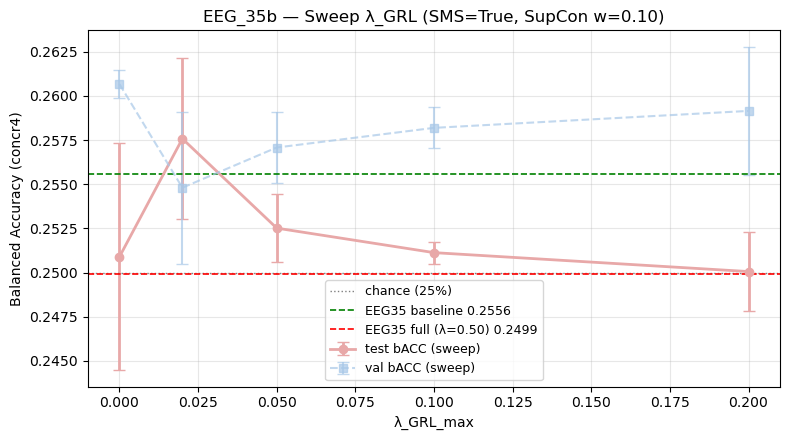

In [8]:
# ====================== §5.1 — Tabella + plot sweep λ ======================
if results:
    import pandas as pd
    lam_vals = [0.0, 0.02, 0.05, 0.10, 0.20]

    rows = []
    for lam_val in lam_vals:
        name = f'λ{lam_val:.2f}'.replace('0.', 'λ0')
        if name not in results:
            continue
        seed_res = results[name]
        vb = np.array([r['val_bacc'] for r in seed_res])
        tb = np.array([r['test_bacc'] for r in seed_res])
        rows.append(dict(lambda_grl=lam_val, config=name,
                         val_bacc=vb.mean(), val_std=vb.std(),
                         test_bacc=tb.mean(), test_std=tb.std()))
    res_df = pd.DataFrame(rows)

    # Aggiungi risultati EEG_35 come riferimento (non rieseguiti)
    ref_rows = [
        dict(lambda_grl=0.50, config='EEG35_full(ref)', val_bacc=0.2547, val_std=0.0016,
             test_bacc=0.2499, test_std=0.0011),
        dict(lambda_grl=float('nan'), config='EEG35_baseline(ref)', val_bacc=0.2608, val_std=0.0035,
             test_bacc=0.2556, test_std=0.0025),
    ]
    res_df = pd.concat([res_df, pd.DataFrame(ref_rows)], ignore_index=True)
    print(res_df.to_string(index=False))

    # Plot: λ sul'asse X, test_bacc sull'asse Y (solo run freschi)
    fresh = res_df[res_df.config.str.startswith('λ')]
    ref_baseline = 0.2556  # da EEG_35
    ref_full50   = 0.2499  # da EEG_35

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.errorbar(fresh.lambda_grl, fresh.test_bacc, yerr=fresh.test_std,
                fmt='o-', color='#E8A8A8', capsize=4, lw=2, label='test bACC (sweep)')
    ax.errorbar(fresh.lambda_grl, fresh.val_bacc,  yerr=fresh.val_std,
                fmt='s--', color='#A8C8E8', capsize=4, lw=1.5, alpha=0.7, label='val bACC (sweep)')
    ax.axhline(1/N_CLASSES, ls=':', color='gray', lw=1, label='chance (25%)')
    ax.axhline(ref_baseline, ls='--', color='green', lw=1.2,
               label=f'EEG35 baseline {ref_baseline:.4f}')
    ax.axhline(ref_full50, ls='--', color='red', lw=1.2,
               label=f'EEG35 full (λ=0.50) {ref_full50:.4f}')
    ax.set_xlabel('λ_GRL_max'); ax.set_ylabel('Balanced Accuracy (concr4)')
    ax.set_title('EEG_35b — Sweep λ_GRL (SMS=True, SupCon w=0.10)')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    plt.tight_layout()
    out = FIG_DIR / 'eeg35b_lambda_sweep.png'
    plt.savefig(out, dpi=150, bbox_inches='tight'); log.info(f'Figura: {out}')
    plt.show()
else:
    print('Nessun risultato. Esegui sul server.')


## §6 — Come leggere i risultati

| Esito | Interpretazione |
|-------|-----------------|
| Peak test_bACC a λ basso (0.02–0.10) > baseline | GRL utile ma era troppo aggressivo. λ ottimale da usare in EEG_36. |
| Monotona decrescita al crescere di λ | GRL distrugge sempre segnale semantico — rimozione soggetto non aiuta. Conferma ceiling strutturale. |
| λ=0.0 (SMS+SupCon) > baseline | È SupCon che aiuta, non GRL. |
| Nessuna differenza da chance | Il problema è strutturale: segnale semantico cross-subject ≤ rumore. |